In [57]:
import torch
from torch.utils.data import Dataset
from glob import glob
from PIL import Image
from pathlib import Path
from dataset import DunexDataset
from network import ResNetUNet
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from notebooks.video_io import write_sequence_to_mp4, show_breakers_on_frame


%load_ext autoreload
%autoreload 2

plt.rcParams['image.origin'] = 'lower'  # Set default origin to lower
plt.rcParams['image.cmap'] = 'gray'  # Set default origin to lower

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

# Initialize model
model = ResNetUNet(n_class=1)

# Load the saved state dictionary
state_dict = torch.load('best_model_11052024.pt', map_location=device)

# Load state dictionary into model
model.load_state_dict(state_dict)

# Move model to device
model = model.to(device)

# Set model to evaluation mode if you're going to use it for inference
model.eval()

/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/mleclair/phd/code/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNetUNet(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [59]:
import sys
sys.path.append('..')  # Add parent directory to Python path
from notebooks.video_io import load_frames
ts = load_frames('/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211011T140100Z_RectifiedVideo.avi') # Unseen
ts = load_frames('/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211014T123100Z_RectifiedVideo.avi')[0:1000] # From Training Set 
ts = load_frames('/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211014T120100Z_RectifiedVideo.avi')[1500:2500] # From Training Set 
ts = load_frames('/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211013T170100Z_RectifiedVideo.avi')[0:250] # From Training Set 
ts = load_frames('/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211028T153100Z_RectifiedVideo.avi')[2000:3000] # From Training Set 
ts = load_frames('/Users/mleclair/phd/code/dunex/data/argus/ArgusFF_20211014T130100Z_RectifiedVideo.avi')[1000:2000] # From Training Set 

img = ts[:, 0, :].T
plt.imshow(ts[:, 0, :].T)
plt.imshow(img, cmap='gray')

3.072gb allocated


Building Timestack: 100%|██████████| 3840/3840 [00:04<00:00, 828.18it/s]


3.072gb allocated


Building Timestack:  52%|█████▏    | 1990/3840 [00:02<00:02, 907.67it/s]


KeyboardInterrupt: 

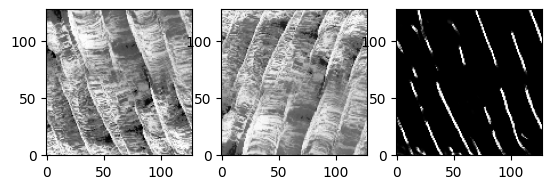

In [6]:
# patch = ts[100:100+128, 800, 100:100+128].T
# pred = predict_patch(model, patch, device=device)
# fig, axs = plt.subplots(1, 3)
# axs[0].imshow(patch)
# axs[1].imshow((preprocess_image(patch).squeeze().permute(1, 2, 0)))
# axs[2].imshow(np.flip(pred, 0))


In [7]:
from predict import *
if len(img.shape) == 2:
    img = (img - img.mean()) / img.std()  # Normalize if needed

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
breakers = np.zeros_like(ts, dtype=float)
for i in tqdm(range(1600)):
    b = predict_large_image(model, ts[:, i, :].T/255.0, patch_size=128, overlap=32, batch_size=64, device=device).T
    breakers[:, i, :] = b

  0%|          | 0/1600 [00:00<?, ?it/s]

In [ ]:
datetime = get_datestring(fname)
write_sequence_to_mp4(breakers, f'results/20241118/{datetime}_breakers.mp4', FPS=2, color=False)
write_sequence_to_mp4((ts).astype(np.uint8) , 'results/20241118/breaker_highlight.mp4', fn=show_breakers_on_frame, FPS=2, data=breakers)

In [9]:
FPS = 2
FRAMES = 1000
SECONDS = FRAMES / FPS
print(SECONDS)

500.0


Text(0.5, 1.0, 'Breakers/sec')

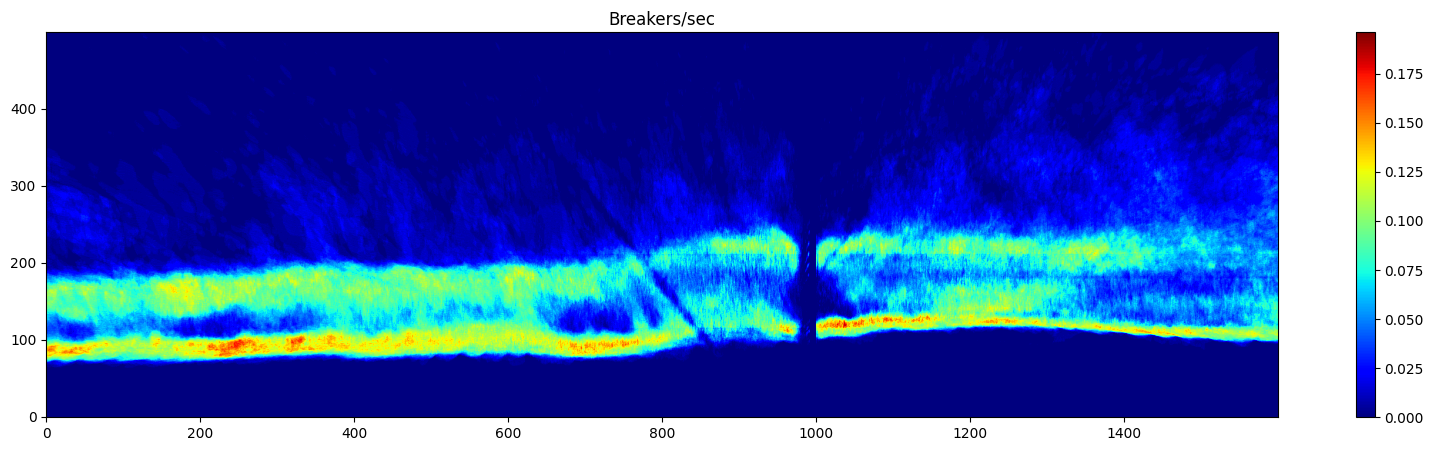

In [10]:
plt.figure(figsize=(20, 5))
plt.imshow((breakers > 0.5).sum(0).T/SECONDS, cmap='jet')
plt.colorbar()
plt.title(f'Breakers/sec')

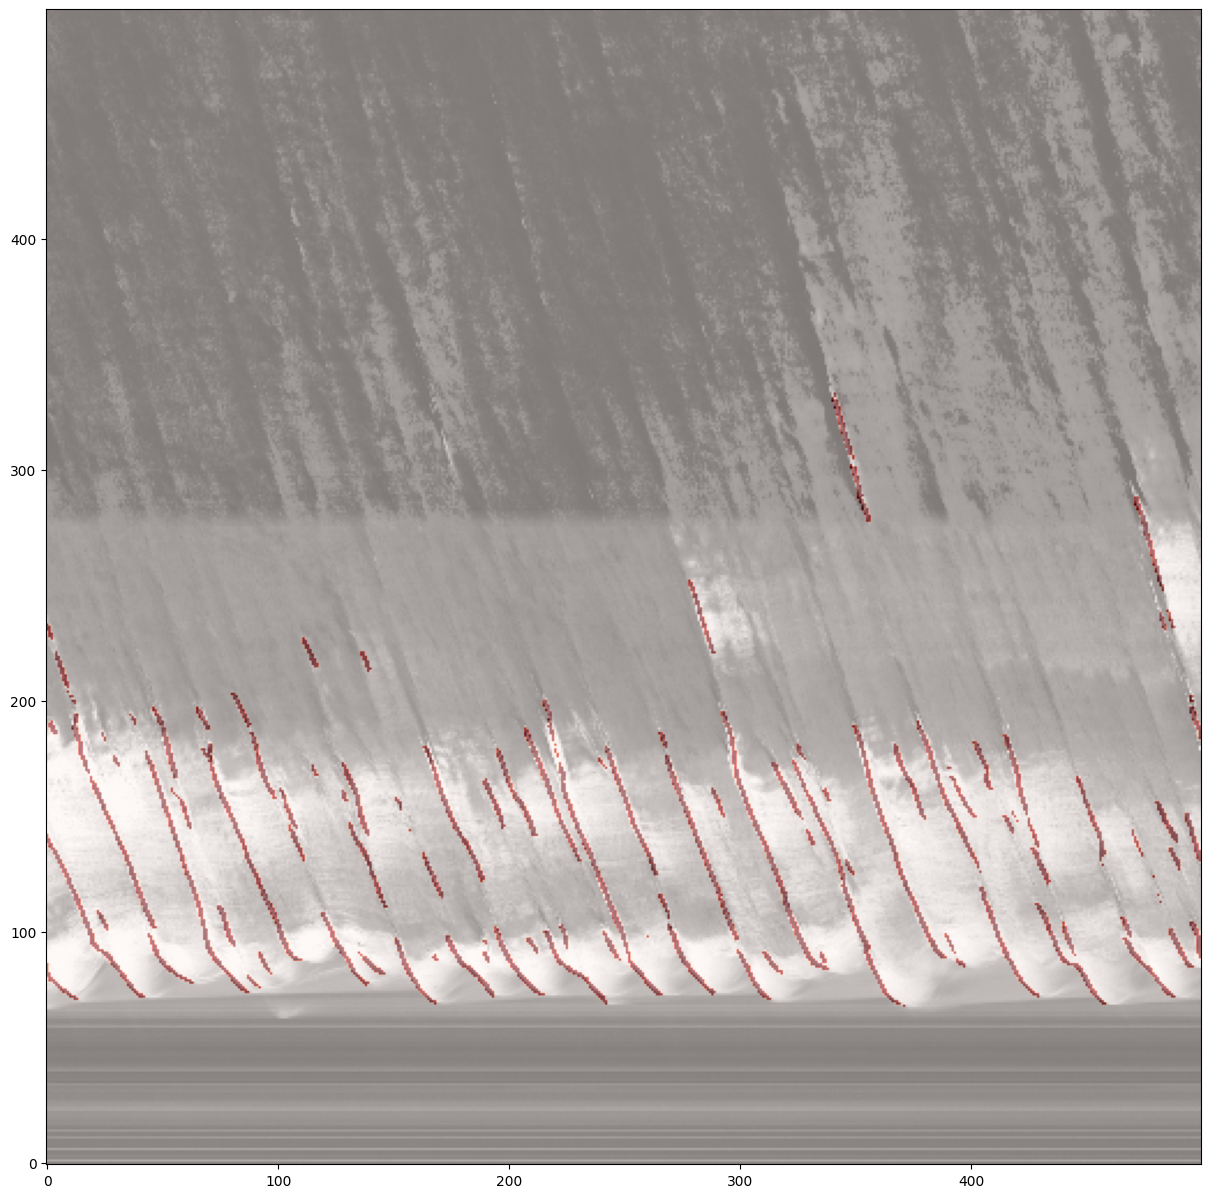

In [46]:
fig, axs = plt.subplots(1,1, figsize=(20, 15))
y=100
axs.imshow(ts[:, y, :].T)
axs.imshow(breakers[:, y, :].T > 0.5, cmap='Reds', alpha=0.5)

In [48]:
from scipy import ndimage, stats
import numpy as np
y=100
binary_image = breakers[:, y, :].T > 0.1

# Find all connected components
# structure defines connectivity: 
#   None or structure=np.ones((3,3)) for 8-connectivity
#   structure=[[0,1,0], [1,1,1], [0,1,0]] for 4-connectivity
labels, num_features = ndimage.label(binary_image, structure=np.ones((3,3)))

# To get properties of each component:
# Get areas
areas = ndimage.sum(binary_image, labels, range(1, num_features + 1))

# Get centroids
centroids = ndimage.center_of_mass(binary_image, labels, range(1, num_features + 1))

# Get bounding boxes (min_row, min_col, max_row, max_col)
boxes = ndimage.find_objects(labels)

# To work with individual components:
for label in range(1, num_features + 1):
    # Create mask for this component
    component_mask = (labels == label)
    
    # Get area
    area = areas[label-1]
    
    # Get centroid (y, x)
    cy, cx = centroids[label-1]
    
    # Get bounding box
    bbox = boxes[label-1]
    # Access as: binary_image[bbox] to get the slice
    
    
from scipy import ndimage, stats
import numpy as np

min_size = 10
durations = []  # Will store time lengths
slopes = []     # Will store slopes
filtered_labels = np.zeros_like(labels)
filtered_areas = np.zeros_like(areas)
component_properties = []

for label in range(1, num_features + 1):
    component_size = areas[label-1]
    if min_size < component_size:
        # Get the component mask
        component_mask = (labels == label)
        filtered_labels[labels == label] = label
        filtered_areas[label-1] = component_size
        
        # Get coordinates of points in the component
        cross_shore, time = np.nonzero(component_mask)  # y is cross-shore, x is time
        
        # Calculate duration in time
        duration = np.max(time) - np.min(time) + 1
        
        # Calculate slope (Δcross-shore/Δtime)
        if len(time) > 1:  # Need at least 2 points for slope
            slope, _, _, _, _ = stats.linregress(time, cross_shore)
        else:
            slope = 0
            
        component_properties.append({
            'label': label,
            'area': component_size,
            'duration': duration,
            'slope': slope,
            'time_start': np.min(time),
            'time_end': np.max(time),
            'cross_shore_start': np.min(cross_shore),
            'cross_shore_end': np.max(cross_shore),
            'centroid': centroids[label-1]
        })
        
        durations.append(duration)
        slopes.append(slope)

# Print first few components to verify calculations
print("\nComponent Statistics:")
for prop in component_properties[:5]:  # First 5 components
    print(f"\nLabel {prop['label']}:")
    print(f"  Duration (time): {prop['duration']}")
    print(f"  Slope (Δcross-shore/Δtime): {prop['slope']:.3f}")
    print(f"  Area: {prop['area']}")


Component Statistics:

Label 1:
  Duration (time): 50
  Slope (Δcross-shore/Δtime): -2.508
  Area: 253.0

Label 2:
  Duration (time): 32
  Slope (Δcross-shore/Δtime): -1.396
  Area: 118.0

Label 3:
  Duration (time): 19
  Slope (Δcross-shore/Δtime): -1.689
  Area: 76.0

Label 4:
  Duration (time): 29
  Slope (Δcross-shore/Δtime): -0.994
  Area: 112.0

Label 5:
  Duration (time): 15
  Slope (Δcross-shore/Δtime): -0.985
  Area: 42.0


Text(0, 0.5, 'Cross-shore')

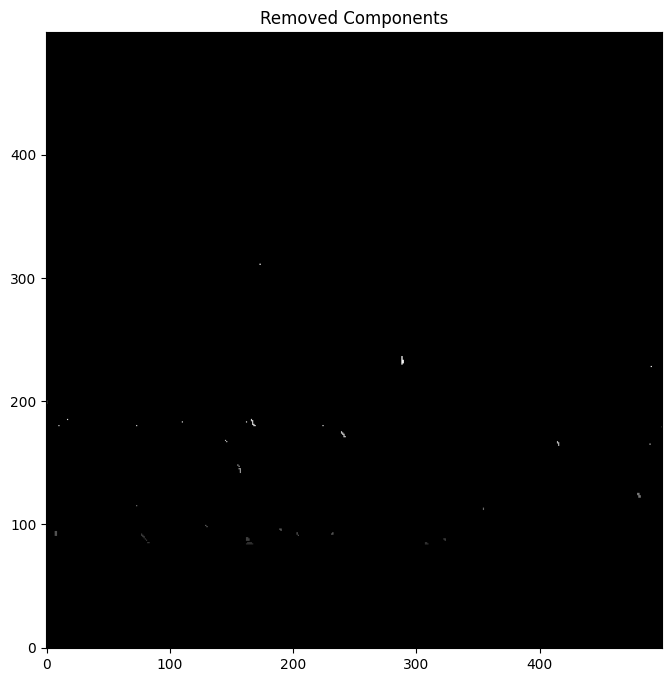

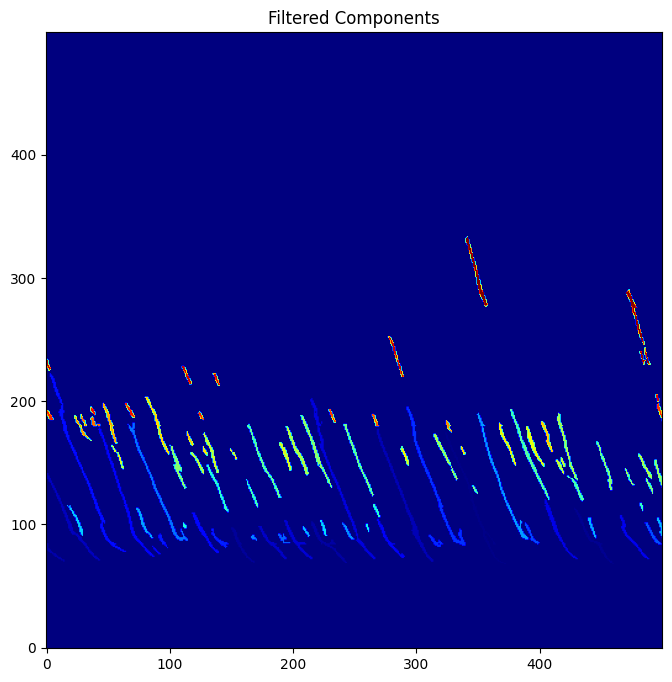

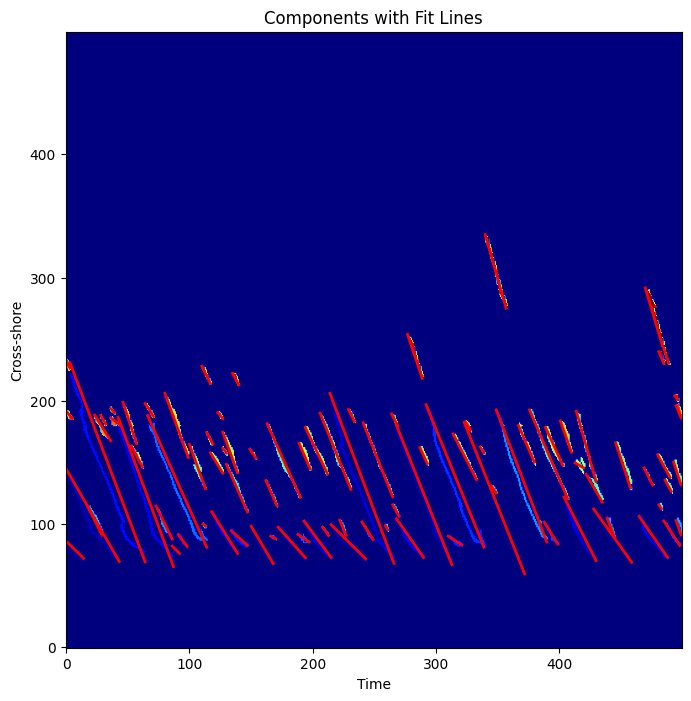

In [49]:
# Visualization with original plots
plt.figure(figsize=(20, 8))
plt.imshow(labels - filtered_labels)
plt.title('Removed Components')

plt.figure(figsize=(20, 8))
plt.imshow(filtered_labels, cmap='jet')
plt.title('Filtered Components')

# Optional: Add visualization of slopes
plt.figure(figsize=(20, 8))
plt.imshow(filtered_labels, cmap='jet')

# For each component, plot its linear fit line
for prop in component_properties:
    # Get time range for this component
    t_start = prop['time_start']
    t_end = prop['time_end']
    
    # Create time points for the line
    t = np.array([t_start, t_end])
    
    # Calculate corresponding cross-shore points using slope and center point
    slope = prop['slope']
    center_time = (t_start + t_end) / 2
    center_cross = (prop['cross_shore_start'] + prop['cross_shore_end']) / 2
    
    # Calculate line points: cross = slope * (t - center_time) + center_cross
    cross = slope * (t - center_time) + center_cross
    
    # Plot the line
    plt.plot(t, cross, 'r-', linewidth=2)

plt.title('Components with Fit Lines')
plt.xlabel('Time')
plt.ylabel('Cross-shore')

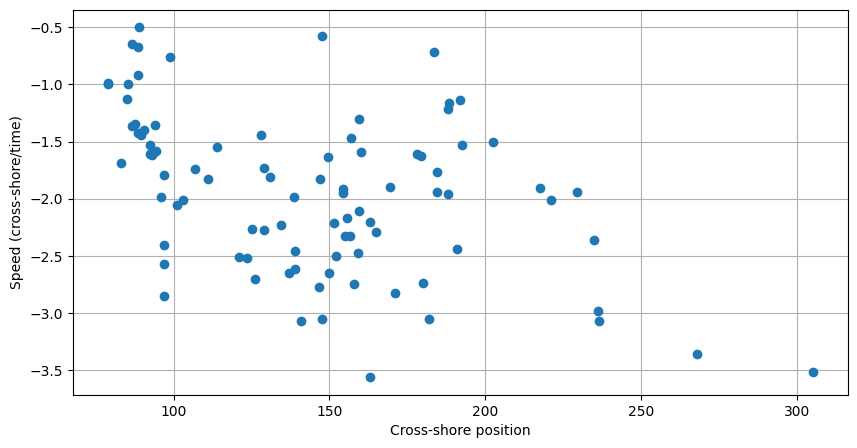

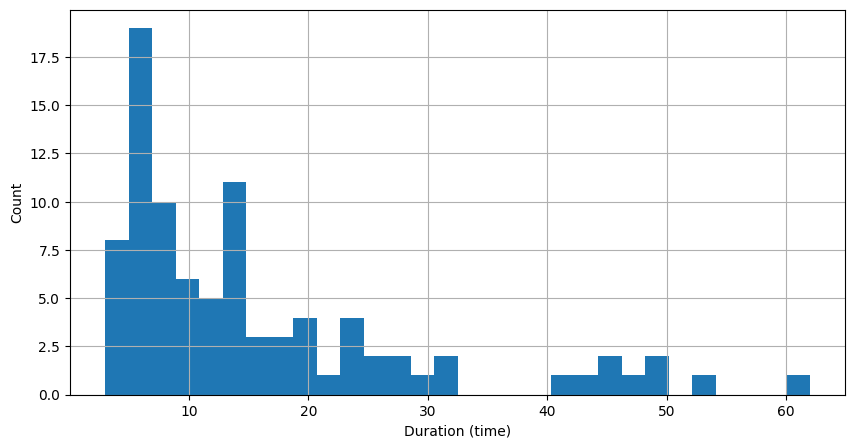

In [24]:
# Distribution of speeds vs cross-shore
plt.figure(figsize=(10, 5))
center_cross_positions = [(prop['cross_shore_start'] + prop['cross_shore_end'])/2 for prop in component_properties]
speeds = [prop['slope'] for prop in component_properties]  # slope is already Δcross/Δtime
plt.plot(center_cross_positions, speeds, 'o')
plt.xlabel('Cross-shore position')
plt.ylabel('Speed (cross-shore/time)')
plt.grid(True)

# Histogram of durations
plt.figure(figsize=(10, 5))
durations = [prop['duration'] for prop in component_properties]
plt.hist(durations, bins=30)
plt.xlabel('Duration (time)')
plt.ylabel('Count')
plt.grid(True)

<ErrorbarContainer object of 3 artists>

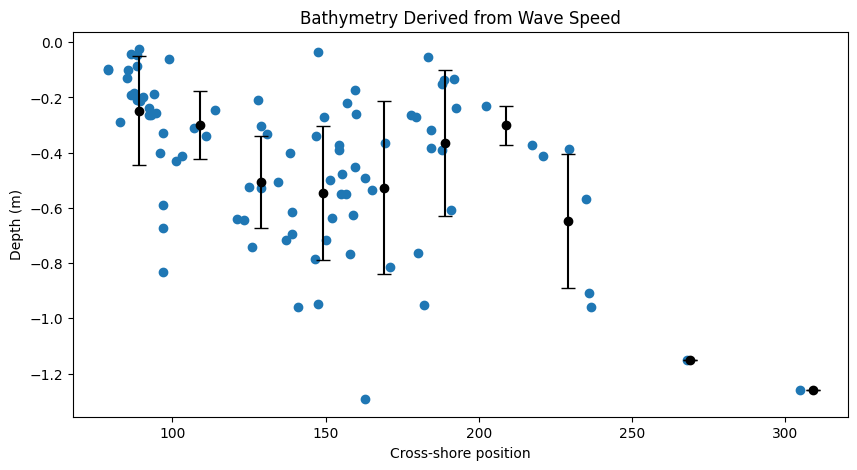

In [25]:
# Calculate depth from speed
g = 9.81  # gravitational acceleration in m/s²
speeds = np.abs(speeds)  # Use speed magnitude
depths = -(speeds**2) / g

plt.figure(figsize=(10, 5))
plt.plot(center_cross_positions, depths, 'o')
plt.xlabel('Cross-shore position')
plt.ylabel('Depth (m)')
plt.title('Bathymetry Derived from Wave Speed')

bin_size = 20
bins = np.arange(min(center_cross_positions), max(center_cross_positions) + bin_size, bin_size)
bin_centers = bins[:-1] + bin_size/2

mean_depths = []
std_depths = []
for i in range(len(bins)-1):
   # Find depths in this bin
   mask = (center_cross_positions >= bins[i]) & (center_cross_positions < bins[i+1])
   bin_depths = depths[mask]
   if len(bin_depths) > 0:  # Only include bins with data
       mean_depths.append(np.mean(bin_depths))
       std_depths.append(np.std(bin_depths))
   else:
       mean_depths.append(np.nan)
       std_depths.append(np.nan)

mean_depths = np.array(mean_depths)
std_depths = np.array(std_depths)

plt.errorbar(bin_centers, mean_depths, yerr=std_depths, fmt='o', capsize=5, c='k')


In [27]:
import numpy as np
from scipy import ndimage, stats
from dataclasses import dataclass
from typing import List, Tuple, Dict, NamedTuple
from joblib import Parallel, delayed
import os
from time import time

@dataclass
class ComponentData:
    label: int
    area: float
    duration: int
    slope: float
    time_start: int
    time_end: int
    cross_shore_start: int
    cross_shore_end: int
    centroid: Tuple[float, float]
    y_position: int

class SliceResult(NamedTuple):
    components: List[ComponentData]
    label_array: np.ndarray
    filtered_binary: np.ndarray

def process_slice(breakers_slice: np.ndarray, y: int, min_size: int = 10) -> SliceResult:
    """Process a single y-slice of the breaker data."""
    binary_slice = breakers_slice.T > 0.5
    labels, num_features = ndimage.label(binary_slice, structure=np.ones((3,3)))
    if num_features == 0:
        return SliceResult([], np.zeros_like(labels), np.zeros_like(binary_slice))
    
    areas = ndimage.sum(binary_slice, labels, range(1, num_features + 1))
    centroids = ndimage.center_of_mass(binary_slice, labels, range(1, num_features + 1))
    
    components = []
    filtered_binary = np.zeros_like(binary_slice)
    filtered_labels = np.zeros_like(labels)
    
    for label in range(1, num_features + 1):
        if areas[label-1] <= min_size:
            continue
            
        component_mask = (labels == label)
        filtered_binary[component_mask] = 1
        filtered_labels[component_mask] = label
        
        cross_shore, time = np.nonzero(component_mask)
        
        if len(np.unique(time)) == 1 or len(np.unique(cross_shore)) == 1:
            continue
        
        slope = 0
        if len(time) > 1:
            slope, *_ = stats.linregress(time, cross_shore)
            
        components.append(ComponentData(
            label=label,
            area=areas[label-1],
            duration=np.max(time) - np.min(time) + 1,
            slope=slope,
            time_start=np.min(time),
            time_end=np.max(time),
            cross_shore_start=np.min(cross_shore),
            cross_shore_end=np.max(cross_shore),
            centroid=centroids[label-1],
            y_position=y
        ))
    
    return SliceResult(components, filtered_labels, filtered_binary)

def process_all_slices_parallel(breakers: np.ndarray, n_jobs: int = -1) -> Tuple[List[ComponentData], np.ndarray, np.ndarray]:
    """
    Process all y-slices of the breaker data in parallel using joblib.
    Returns:
        Tuple containing:
        - List of ComponentData
        - 3D array of filtered labels
        - 3D array of filtered binary masks
    """
    start_time = time()
    
    # Prepare slices
    slices = [(breakers[:, y, :], y) for y in range(breakers.shape[1])]
    
    # Process in parallel
    print(f"Processing {len(slices)} slices using {os.cpu_count() if n_jobs == -1 else n_jobs} workers...")
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_slice)(slice_data, y) 
        for slice_data, y in slices
    )
    
    # Separate results
    all_components = []
    filtered_labels = np.zeros_like(breakers)  # Initialize with correct shape
    filtered_binary = np.zeros_like(breakers)
    
    for y, result in enumerate(results):
        all_components.extend(result.components)
        filtered_labels[:, y, :] = result.label_array.T  # Transpose back to original orientation
        filtered_binary[:, y, :] = result.filtered_binary.T
    
    end_time = time()
    print(f"\nProcessed {len(all_components)} components in {end_time - start_time:.1f} seconds")
    return all_components, filtered_labels, filtered_binary

# Process all slices
all_components, filtered_labels, filtered_binary = process_all_slices_parallel(breakers)

# Calculate bathymetry
g = 9.81
bathymetry_data = {
    'y_positions': [c.y_position for c in all_components],
    'cross_shore_positions': [(c.cross_shore_start + c.cross_shore_end)/2 for c in all_components],
    'speeds': [abs(c.slope) for c in all_components],
    'depths': [-(c.slope**2)/g for c in all_components],
    'duration': [c.duration for c in all_components]
}

Processing 1600 slices using 12 workers...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.11257386207580566s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done  50 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  72 tasks      | elapsed:    0.9s
[Parallel(n_jobs=-1)]: Done  98 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 124 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 154 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 218 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 252 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 290 tasks      | elapsed:    2.9s
[Parallel(n_jobs=-1)]


Processed 147936 components in 17.2 seconds


(array([1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00, 2.0000e+00,
        5.0000e+00, 1.0000e+01, 5.0000e+00, 1.5000e+01, 3.2000e+01,
        5.7000e+01, 4.9000e+01, 1.0100e+02, 1.6700e+02, 2.4600e+02,
        4.2800e+02, 6.6500e+02, 1.0250e+03, 1.3590e+03, 1.9420e+03,
        2.8000e+03, 3.8090e+03, 5.9350e+03, 9.6470e+03, 1.5153e+04,
        1.9210e+04, 2.1718e+04, 2.6281e+04, 2.8062e+04, 9.2080e+03]),
 array([-5.73394495, -5.61926606, -5.50458716, -5.38990826, -5.27522936,
        -5.16055046, -5.04587156, -4.93119266, -4.81651376, -4.70183486,
        -4.58715596, -4.47247706, -4.35779817, -4.24311927, -4.12844037,
        -4.01376147, -3.89908257, -3.78440367, -3.66972477, -3.55504587,
        -3.44036697, -3.32

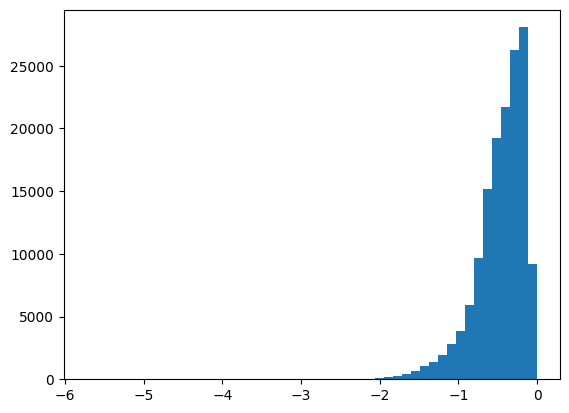

In [28]:
plt.hist(bathymetry_data['depths'], bins=50)

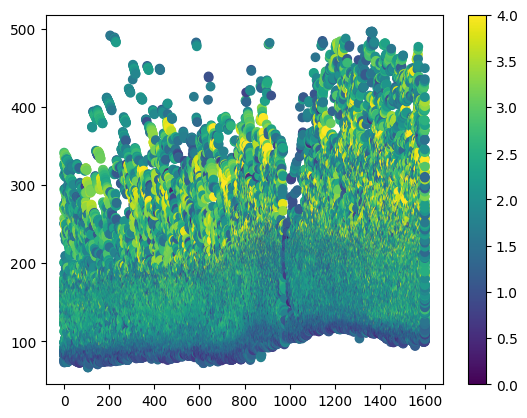

In [29]:
plt.scatter(bathymetry_data['y_positions'], bathymetry_data['cross_shore_positions'], c=bathymetry_data['speeds'], cmap='viridis', vmax=4)
plt.colorbar()

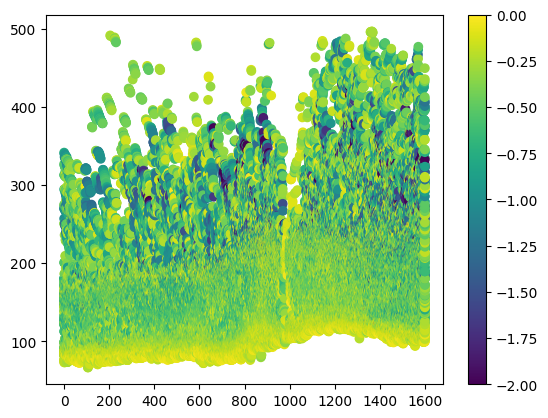

In [30]:
plt.scatter(bathymetry_data['y_positions'], bathymetry_data['cross_shore_positions'], c=bathymetry_data['depths'], vmin=-2, vmax=0, cmap='viridis')
plt.colorbar()

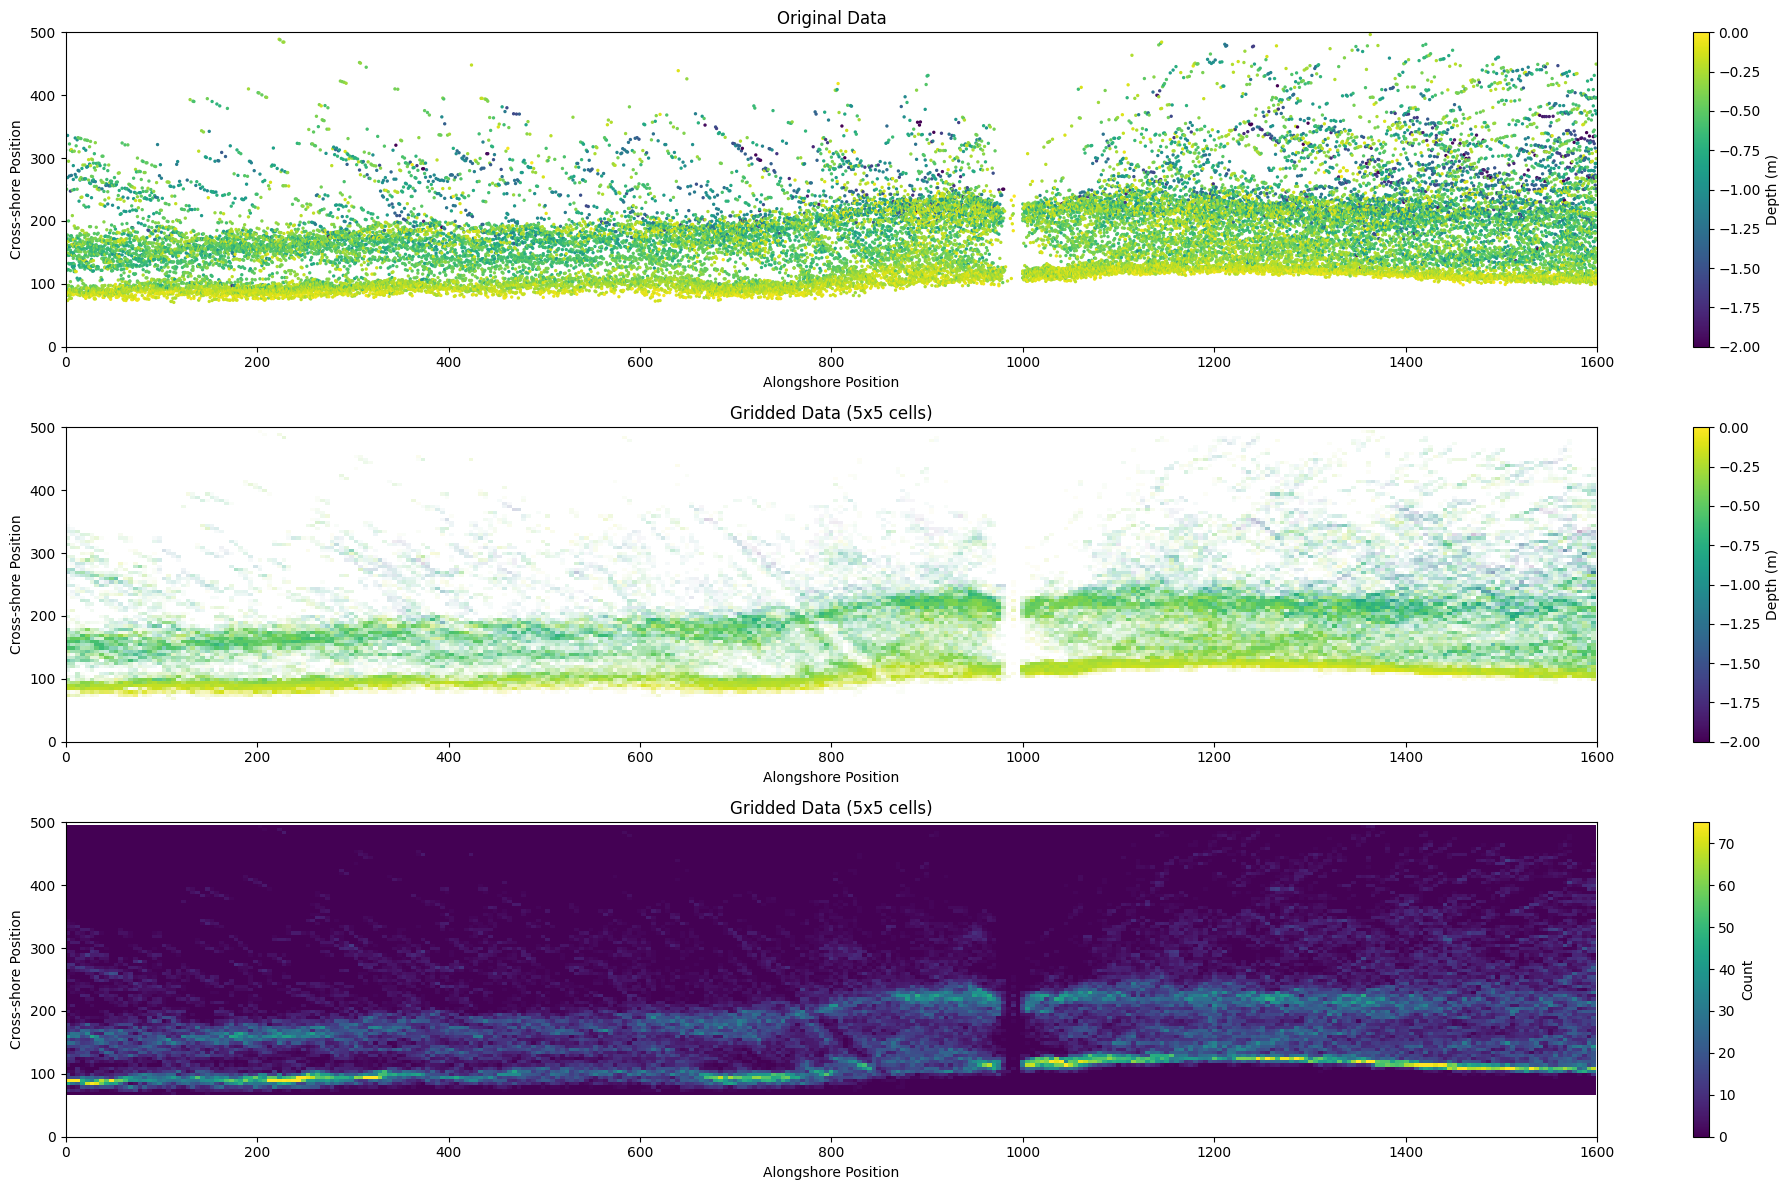

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic_2d

def grid_average_bathymetry(bathymetry_data, grid_size=5):
    """
    Average bathymetry data on a grid.
    
    Args:
        bathymetry_data: Dictionary containing y_positions, cross_shore_positions, and depths
        grid_size: Size of grid cells
    """
    # Get data ranges
    y_min, y_max = min(bathymetry_data['y_positions']), max(bathymetry_data['y_positions'])
    cs_min, cs_max = min(bathymetry_data['cross_shore_positions']), max(bathymetry_data['cross_shore_positions'])
    
    # Calculate number of bins
    n_y_bins = int((y_max - y_min) / grid_size) + 1
    n_cs_bins = int((cs_max - cs_min) / grid_size) + 1
    
    # Create grid bins
    y_bins = np.linspace(y_min, y_max, n_y_bins)
    cs_bins = np.linspace(cs_min, cs_max, n_cs_bins)
    
    # Calculate binned statistics
    gridded_depths, y_edges, cs_edges, binnumber = binned_statistic_2d(
        bathymetry_data['y_positions'],
        bathymetry_data['cross_shore_positions'],
        bathymetry_data['depths'],
        statistic='mean',
        bins=[y_bins, cs_bins]
    )
    
    gridded_counts, _, _, _ = binned_statistic_2d(
        bathymetry_data['y_positions'],
        bathymetry_data['cross_shore_positions'],
        bathymetry_data['depths'],
        statistic='count',
        bins=[y_bins, cs_bins]
    )
    
    # Get grid centers for plotting
    y_centers = (y_edges[:-1] + y_edges[1:]) / 2
    cs_centers = (cs_edges[:-1] + cs_edges[1:]) / 2
    Y, CS = np.meshgrid(y_centers, cs_centers)
    
    # Create figure
    plt.figure(figsize=(20, 12))
    
    # Plot original data
    plt.subplot(311)
    scatter = plt.scatter(bathymetry_data['y_positions'][::5], 
                         bathymetry_data['cross_shore_positions'][::5],
                         c=bathymetry_data['depths'][::5],
                         s=2,
                         vmin=-2, vmax=0, cmap='viridis')
    plt.colorbar(scatter, label='Depth (m)')
    plt.xlim(0, 1600)
    plt.ylim(0, 500)
    plt.xlabel('Alongshore Position')
    plt.ylabel('Cross-shore Position')
    plt.title('Original Data')
    
    # Plot gridded data
    plt.subplot(312)
    mesh = plt.pcolormesh(Y, CS, gridded_depths.T, alpha=np.minimum(1, gridded_counts.T/25),
                         vmin=-2, vmax=0, cmap='viridis')
    plt.xlim(0, 1600)
    plt.ylim(0, 500)
    plt.colorbar(mesh, label='Depth (m)')
    plt.xlabel('Alongshore Position')
    plt.ylabel('Cross-shore Position')
    plt.title(f'Gridded Data ({grid_size}x{grid_size} cells)')
    
    
    # Plot gridded data
    plt.subplot(313)
    mesh = plt.pcolormesh(Y, CS, gridded_counts.T, vmax=75, cmap='viridis')
    plt.xlim(0, 1600)
    plt.ylim(0, 500)
    plt.colorbar(mesh, label='Count')
    plt.xlabel('Alongshore Position')
    plt.ylabel('Cross-shore Position')
    plt.title(f'Gridded Data ({grid_size}x{grid_size} cells)')
    
    plt.tight_layout()
    
    return gridded_depths, Y, CS, gridded_counts

# Calculate and plot gridded bathymetry
gridded_depths, Y, CS, gridded_counts = grid_average_bathymetry(bathymetry_data, grid_size=5)

# Return the gridded data for further use if needed
gridded_bathymetry_data = {
    'depths': gridded_depths,
    'Y': Y,
    'CS': CS
}

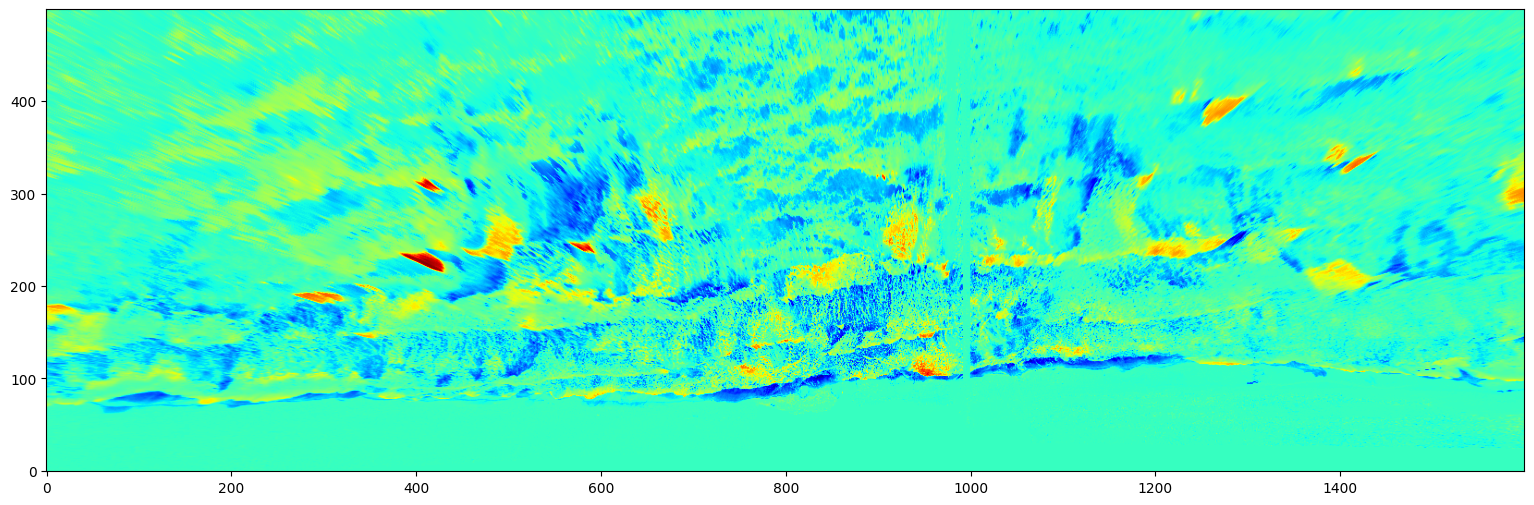

In [42]:
plt.figure(figsize=(20, 6))
plt.imshow((ts[30] - ts[:30].mean(0)).T, cmap='jet')

In [34]:

# write_sequence_to_mp4(filt.astype(np.uint8)*255, 'detected_waves_filt.mp4', FPS=2, color=False)
# write_sequence_to_mp4(ts[2000:3000].astype(np.uint8), 'source.mp4', FPS=2, color=False)


write_sequence_to_mp4((ts).astype(np.uint8) , 'breaker_highlight.mp4', fn=show_breakers_on_frame, FPS=FPS, data=filtered_binary)

100%|██████████| 500/500 [00:06<00:00, 77.11it/s]


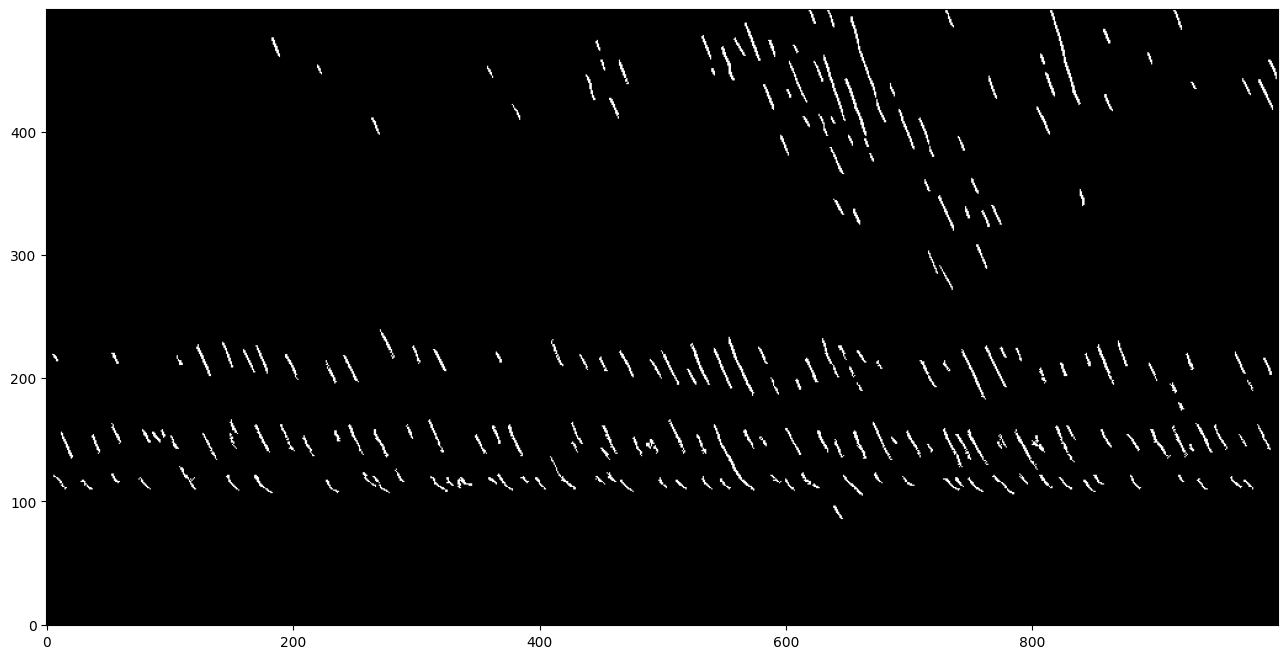

In [41]:
y = 800
plt.figure(figsize=(20, 8))
plt.imshow(filtered_binary[:, y, :].T)


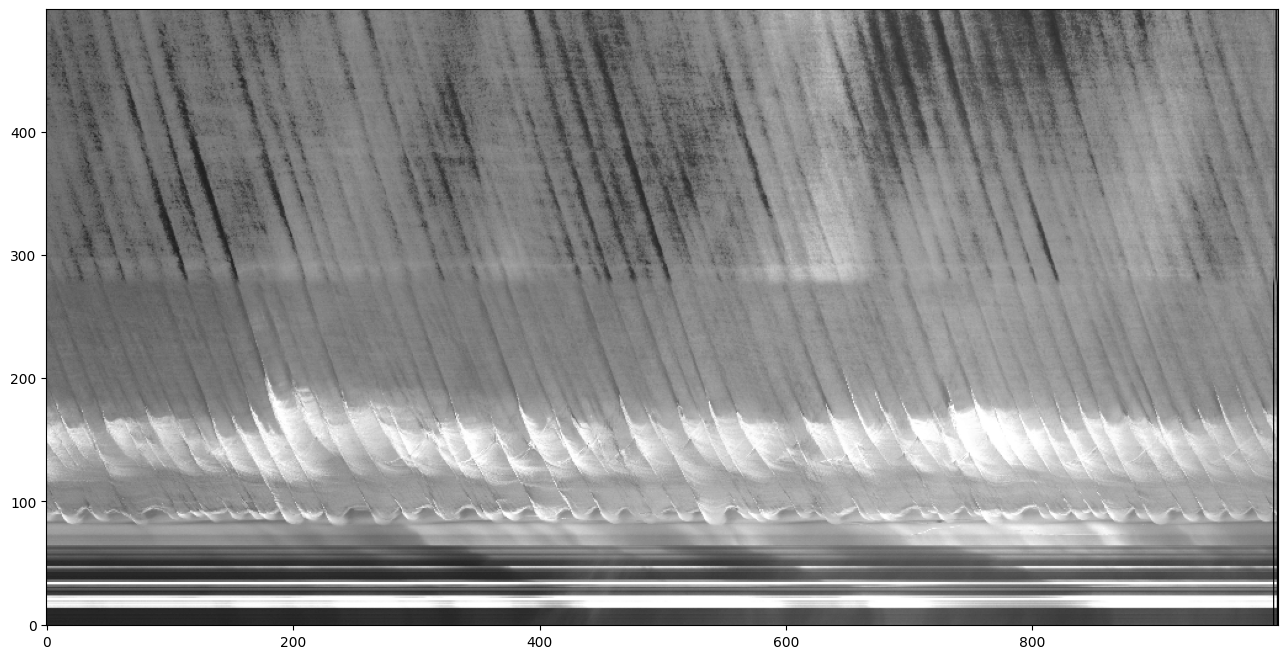

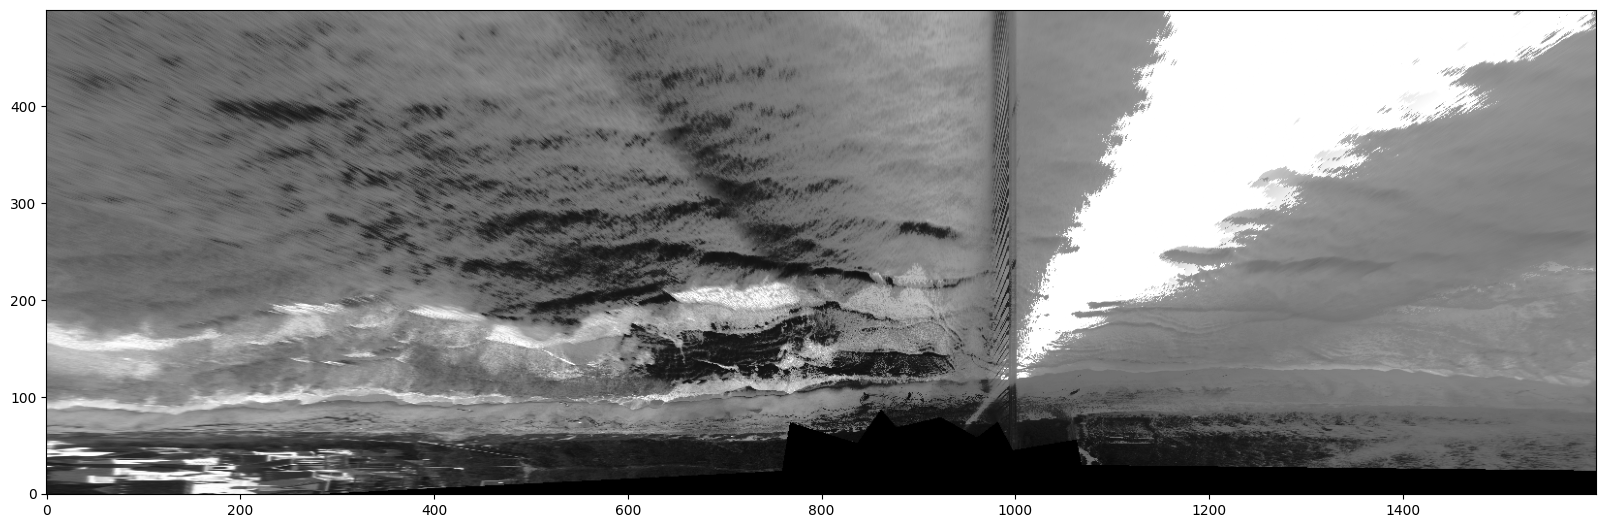

In [40]:
plt.figure(figsize=(20, 8))
plt.imshow(ts[:, y, :].T)

plt.figure(figsize=(20, 8))

plt.imshow(ts[0, :, :].T)

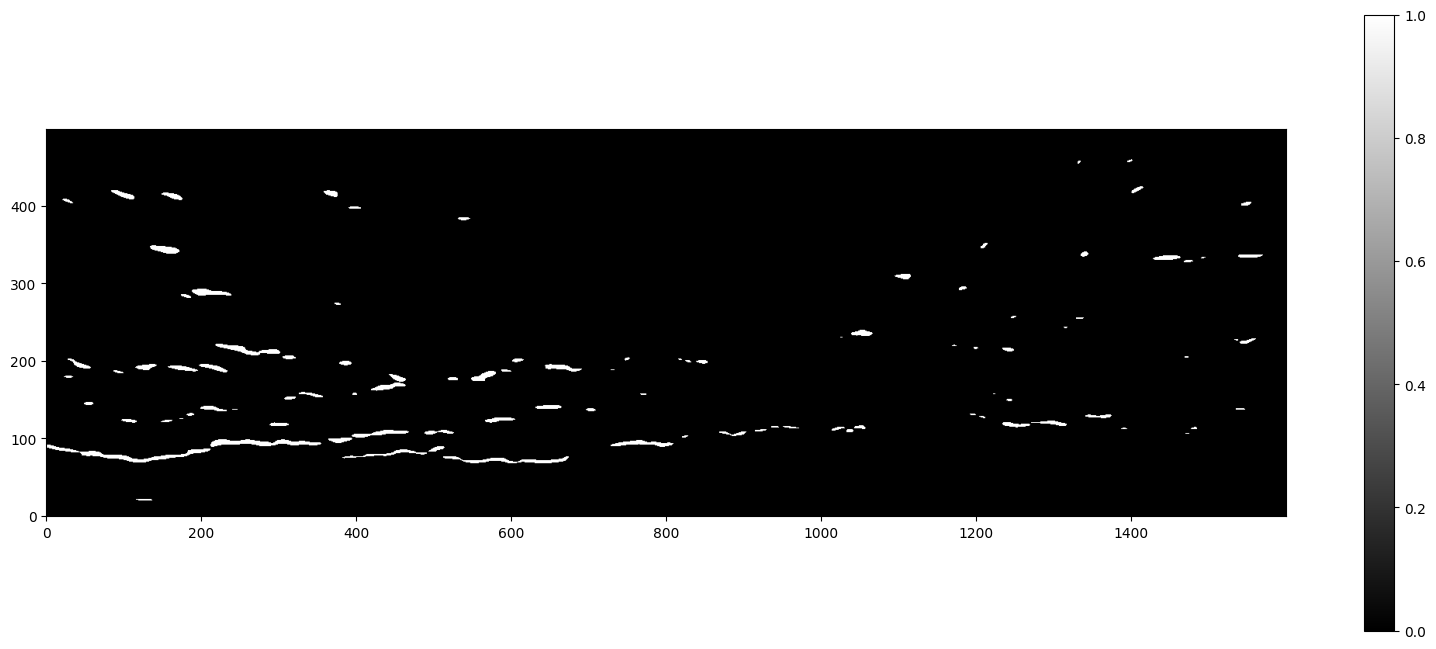

In [363]:

from scipy import ndimage as ndi
plt.figure(figsize=(20, 8))

plt.imshow(ndi.gaussian_filter(breakers[0, :, :], sigma=(5, 1)).T > 0.4)
plt.colorbar()


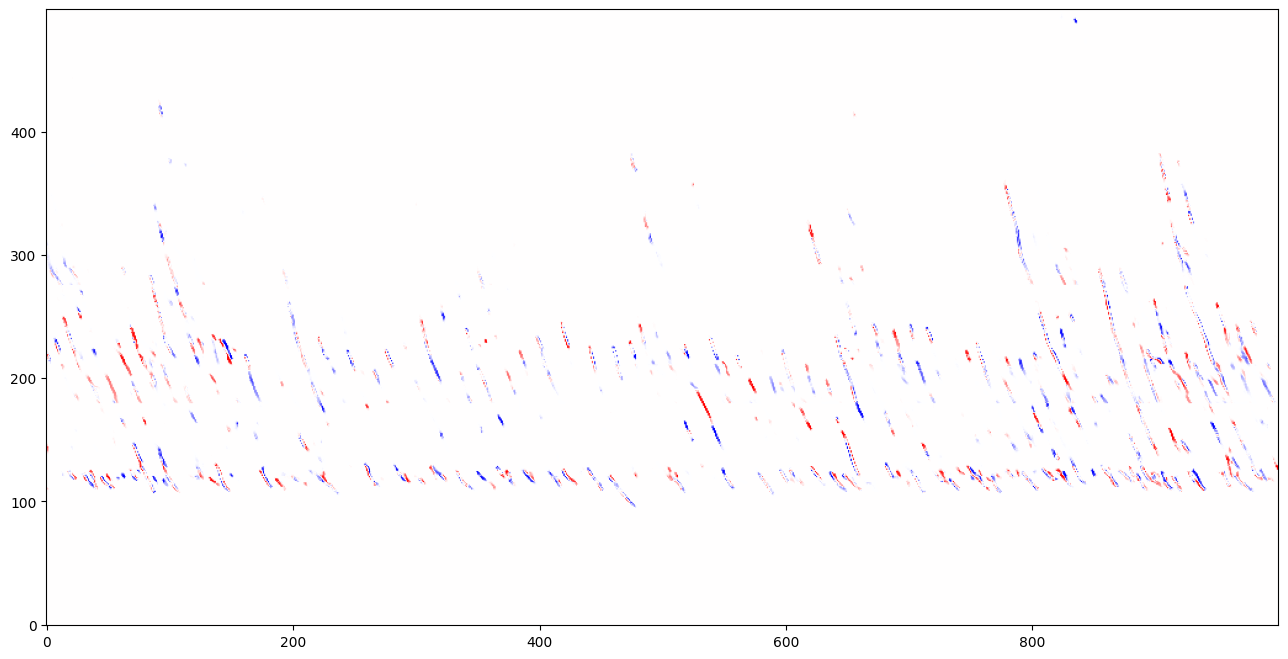

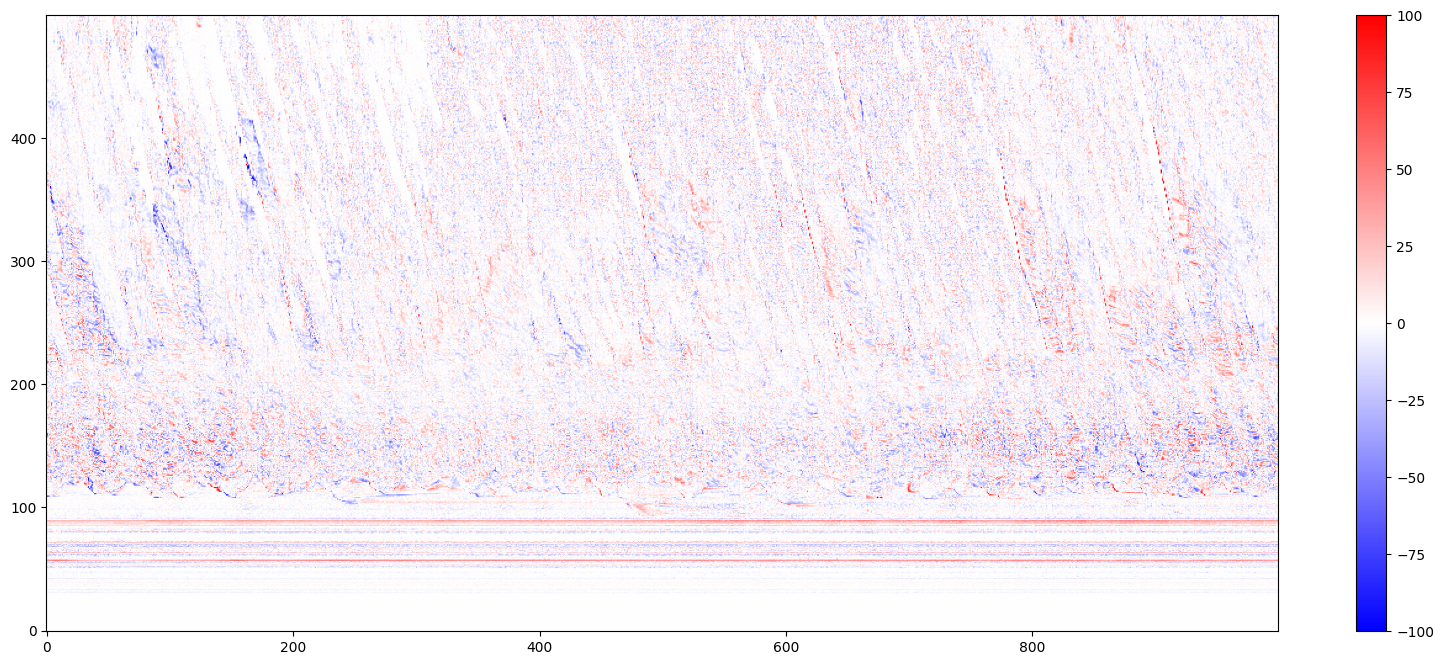

In [350]:
plt.figure(figsize=(20, 8))
plt.imshow((breakers[:, 1100, :] - breakers[:, 1101, :]).T, cmap='bwr')

plt.figure(figsize=(20, 8))
plt.imshow((ts[2000:3000, 1100, :] - ts[2000:3000, 1101, :]).T, cmap='bwr', vmin=-100, vmax=100)
plt.colorbar()


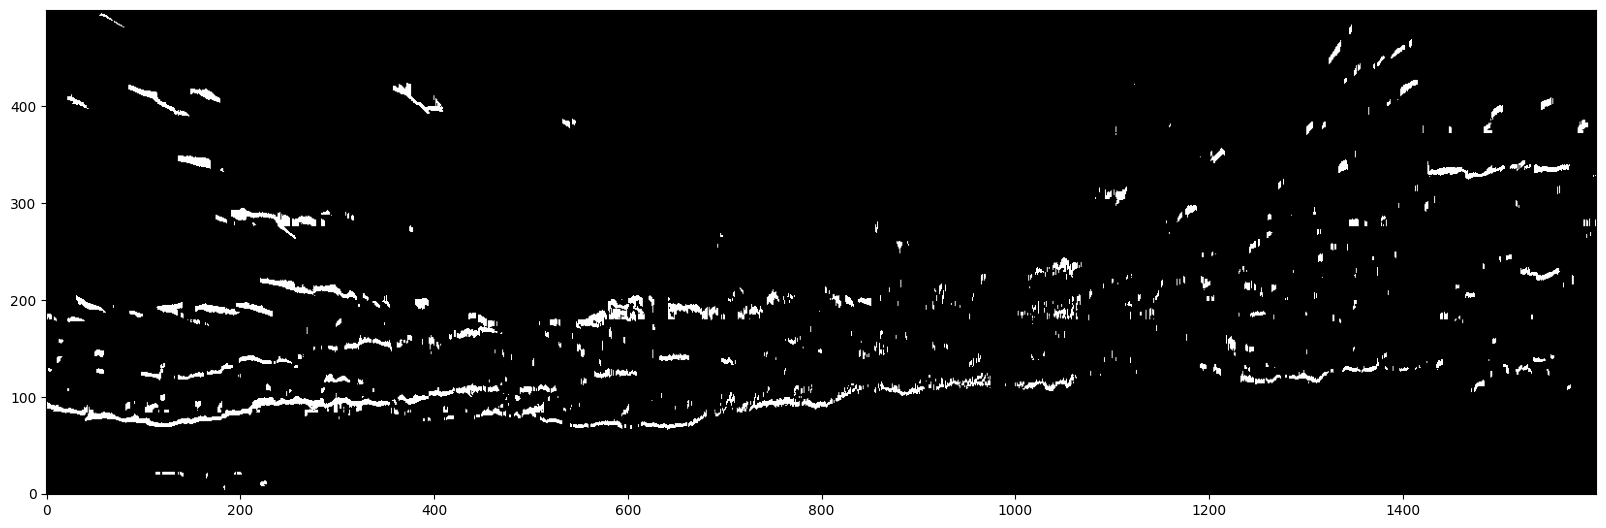

In [227]:
plt.figure(figsize=(20, 8))
plt.imshow(filtered_binary[0].T)

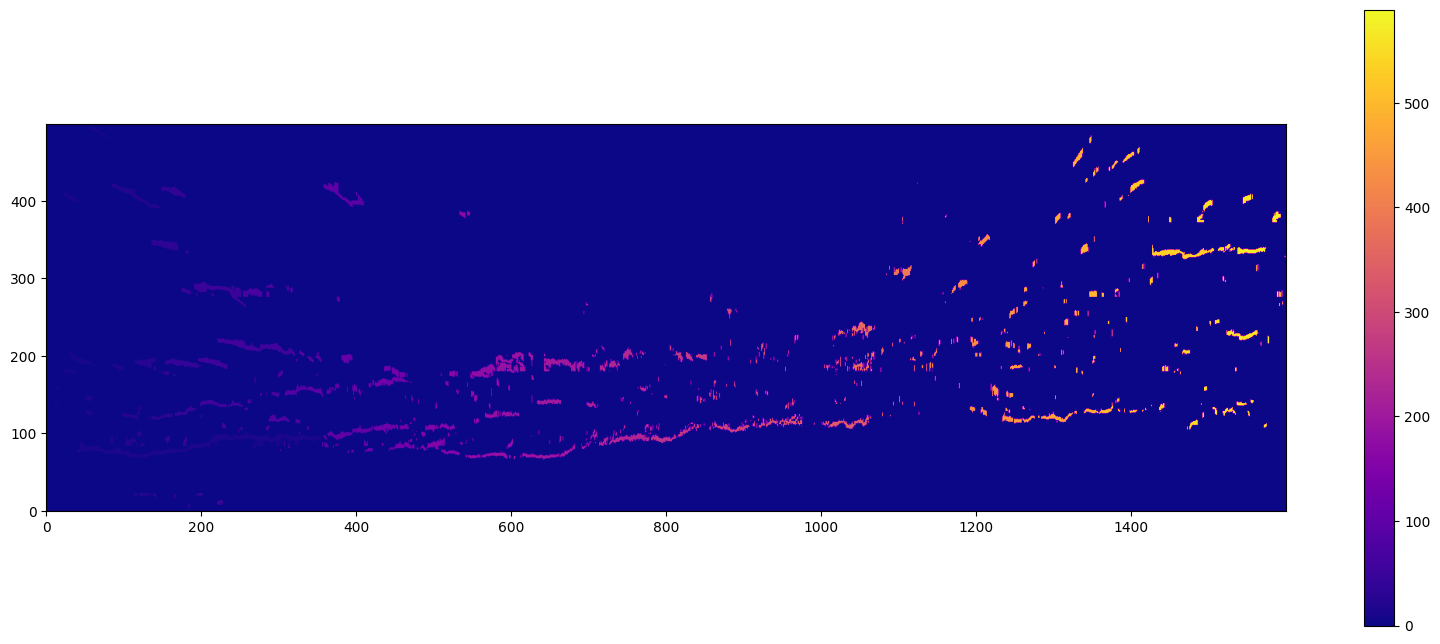

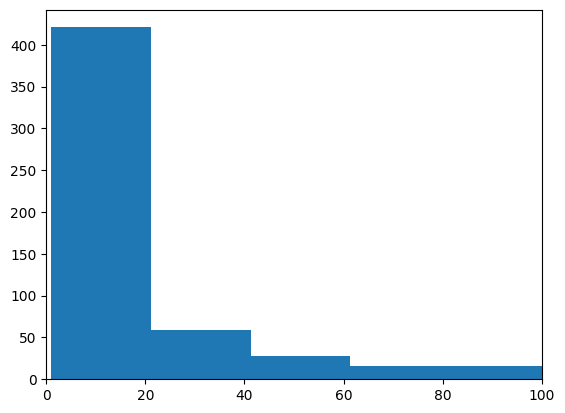

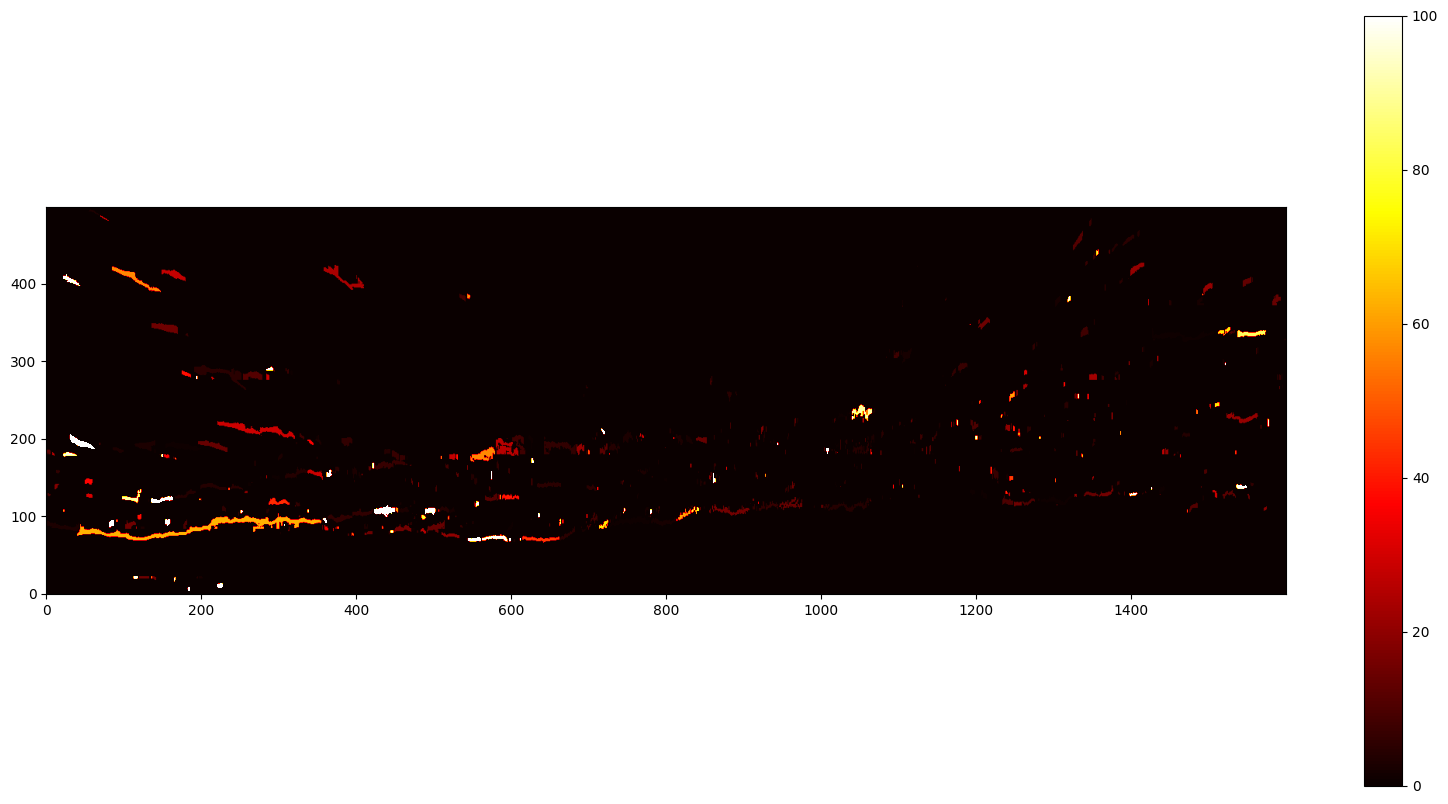

In [340]:
labels, num_features = ndimage.label(filtered_binary[0], structure=np.ones((3,3)))
plt.figure(figsize=(20, 8))
plt.imshow(labels.T, cmap='plasma')
plt.colorbar()
areas = ndimage.sum(filtered_binary[0], labels, range(1, num_features + 1))
plt.figure()
plt.hist(areas, bins=100)
plt.xlim(0, 100)

a = np.zeros_like(labels)
for i in range(1, num_features):
    a[labels==i] = areas[i]
plt.figure(figsize=(20, 10))
plt.imshow(a.T, cmap='hot', vmin=0, vmax=100)
plt.colorbar()


In [241]:
definite_breakers = breakers[:100] > 0.5
labels, num_features = ndimage.label(definite_breakers, structure=np.ones((3,3,3)))
areas = ndimage.sum(definite_breakers, labels, range(1, num_features + 1))
# centroids = ndimage.center_of_mass(definite_breakers, labels, range(1, num_features + 1))


In [298]:
st_filt = np.zeros_like(labels)
for label in tqdm(range(num_features)):
    if areas[label] > 50:
        st_filt[labels==label] = labels[labels==label]


  0%|          | 0/8112 [00:00<?, ?it/s]

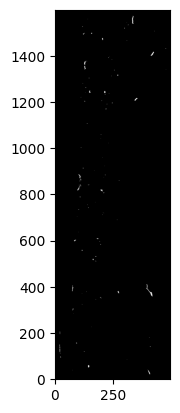

In [300]:
plt.imshow(st_filt[0]!=0)

In [301]:
write_sequence_to_mp4(255*(st_filt!=0).astype(np.uint), 'st_filt.mp4', color=False, FPS=10)

100%|██████████| 100/100 [00:00<00:00, 243.07it/s]


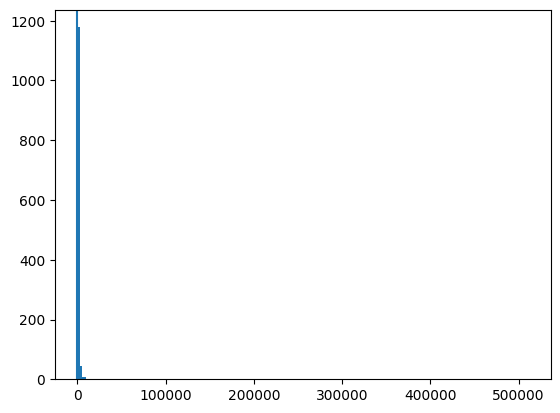

In [295]:
plt.hist(areas[(areas > 50)], bins=200)
plt.axvline(np.percentile(areas, 0.9))
# plt.xlim(0, 55)
# plt.ylim(0, 10)

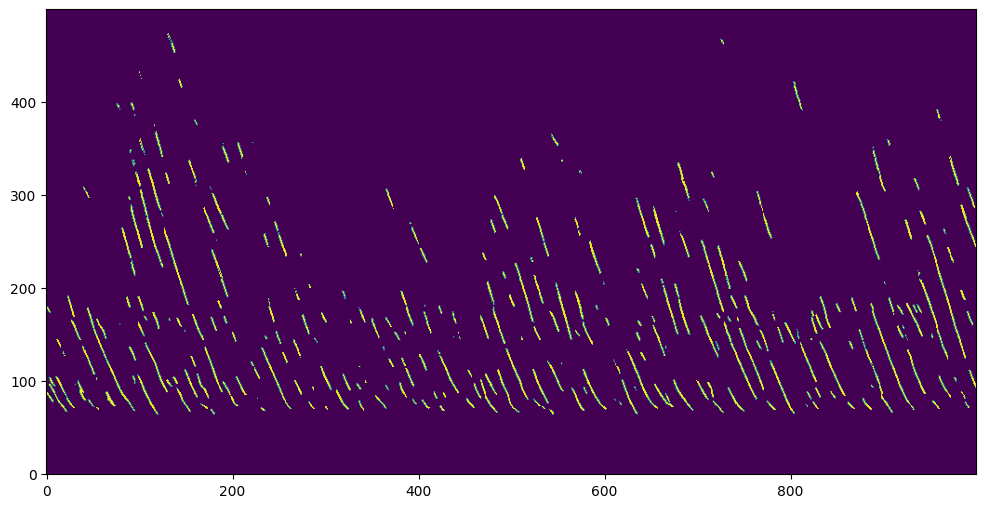

In [315]:
plt.figure(figsize=(12, 10))
plt.imshow(breakers[:, 10, :].T > 0.5, cmap='viridis')